# Per Cell Type DEG Overlap Analysis
## Cirrhosis vs Hepatitis (NT vs TC)
- padj < 0.05, |log2FC| >= 0.5 기준
- 각 셀타입별 Up/Down Venn Diagram

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import warnings
warnings.filterwarnings('ignore')

out_dir = 'results_output'
save_dir = os.path.join(out_dir, 'overlap_genes')
os.makedirs(save_dir, exist_ok=True)

## Hepatocytes

In [2]:
# Hepatocytes 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Hepatocyte.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Hepatocyte.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

# 유의한 DEG 필터링: padj < 0.05 & |log2FC| >= 0.5
cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 12839
Hepatitis total DEGs: 12321
Cirrhosis significant: 9780 (Up: 4331, Down: 5449)
Hepatitis significant: 741 (Up: 325, Down: 416)


In [3]:
76+63

139

In [4]:
63+223

286

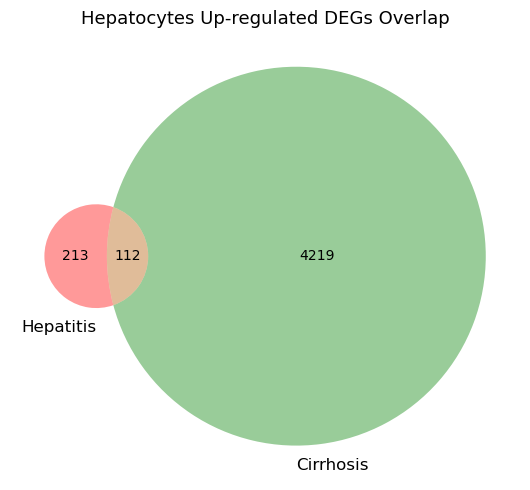

Up-regulated 교집합: 112
Hepatitis only Up: 213
Cirrhosis only Up: 4219


In [5]:
# Hepatocytes Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Hepatocytes Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

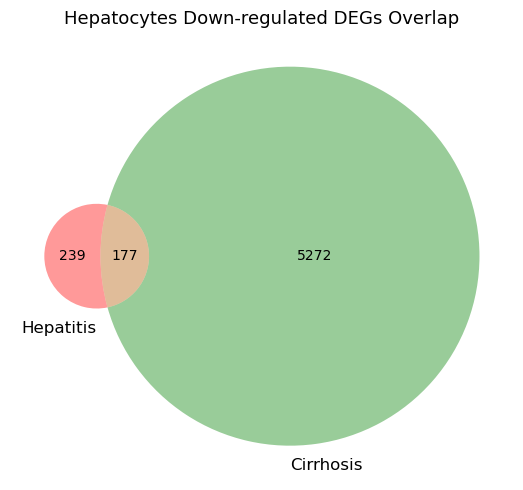

Down-regulated 교집합: 177
Hepatitis only Down: 239
Cirrhosis only Down: 5272


In [6]:
# Hepatocytes Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Hepatocytes Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [7]:
# Hepatocytes overlap 유전자 저장
ct = 'Hepatocyte'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Hepatocyte overlap genes saved:
  Cirrhosis only Up: 4219
  Hepatitis only Up: 213
  Cirrhosis only Down: 5272
  Hepatitis only Down: 239


## T_Cells

In [8]:
# T_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Tcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Tcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 10375
Hepatitis total DEGs: 7208
Cirrhosis significant: 5316 (Up: 3043, Down: 2273)
Hepatitis significant: 1332 (Up: 1009, Down: 323)


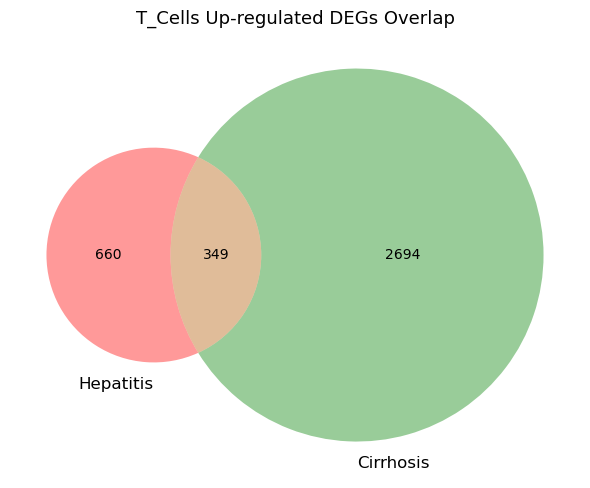

Up-regulated 교집합: 349
Hepatitis only Up: 660
Cirrhosis only Up: 2694


In [9]:
# T_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('T_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

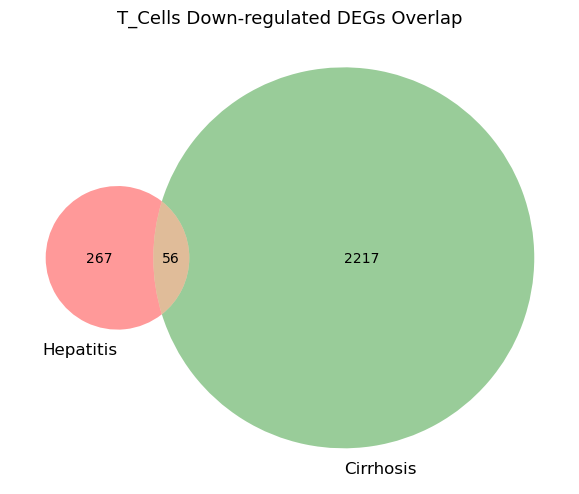

Down-regulated 교집합: 56
Hepatitis only Down: 267
Cirrhosis only Down: 2217


In [10]:
# T_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('T_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [11]:
# T_Cells overlap 유전자 저장
ct = 'Tcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Tcell overlap genes saved:
  Cirrhosis only Up: 2694
  Hepatitis only Up: 660
  Cirrhosis only Down: 2217
  Hepatitis only Down: 267


## Mesenchymal

In [12]:
# Mesenchymal 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Mesenchymal.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Mesenchymal.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 13451
Hepatitis total DEGs: 9911
Cirrhosis significant: 6888 (Up: 3485, Down: 3403)
Hepatitis significant: 2499 (Up: 1802, Down: 697)


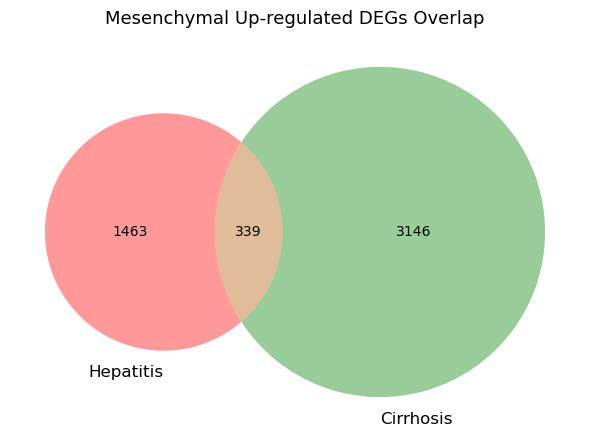

Up-regulated 교집합: 339
Hepatitis only Up: 1463
Cirrhosis only Up: 3146


In [13]:
# Mesenchymal Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Mesenchymal Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

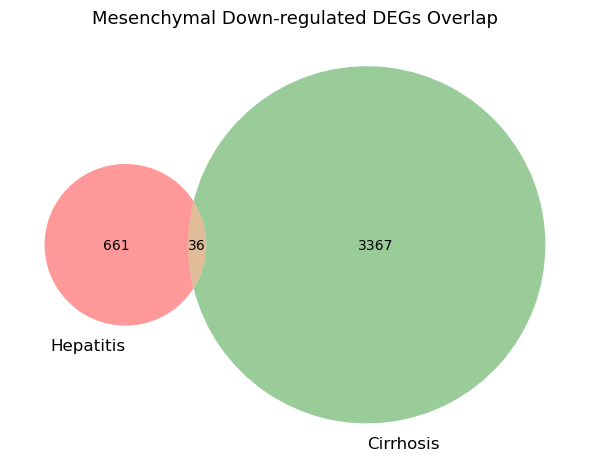

Down-regulated 교집합: 36
Hepatitis only Down: 661
Cirrhosis only Down: 3367


In [14]:
# Mesenchymal Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Mesenchymal Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [15]:
# Mesenchymal overlap 유전자 저장
ct = 'Mesenchymal'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Mesenchymal overlap genes saved:
  Cirrhosis only Up: 3146
  Hepatitis only Up: 1463
  Cirrhosis only Down: 3367
  Hepatitis only Down: 661


## Macrophages

In [16]:
# Macrophages 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Macrophage.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Macrophage.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 9940
Hepatitis total DEGs: 9568
Cirrhosis significant: 1464 (Up: 889, Down: 575)
Hepatitis significant: 1007 (Up: 653, Down: 354)


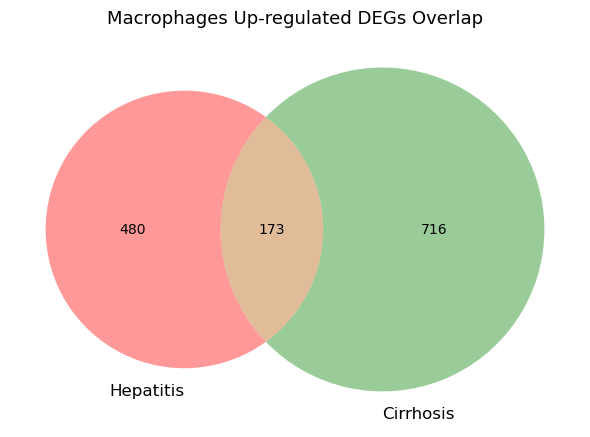

Up-regulated 교집합: 173
Hepatitis only Up: 480
Cirrhosis only Up: 716


In [17]:
# Macrophages Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Macrophages Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

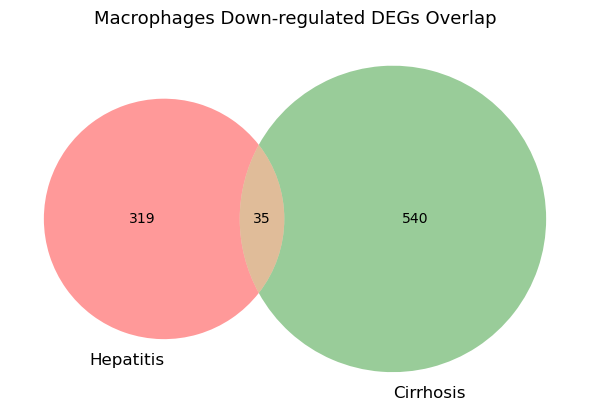

Down-regulated 교집합: 35
Hepatitis only Down: 319
Cirrhosis only Down: 540


In [18]:
# Macrophages Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Macrophages Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [19]:
# Macrophages overlap 유전자 저장
ct = 'Macrophage'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Macrophage overlap genes saved:
  Cirrhosis only Up: 716
  Hepatitis only Up: 480
  Cirrhosis only Down: 540
  Hepatitis only Down: 319


## NK_Cells

In [20]:
# NK_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_NKcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_NKcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 9724
Hepatitis total DEGs: 8334
Cirrhosis significant: 912 (Up: 522, Down: 390)
Hepatitis significant: 1207 (Up: 823, Down: 384)


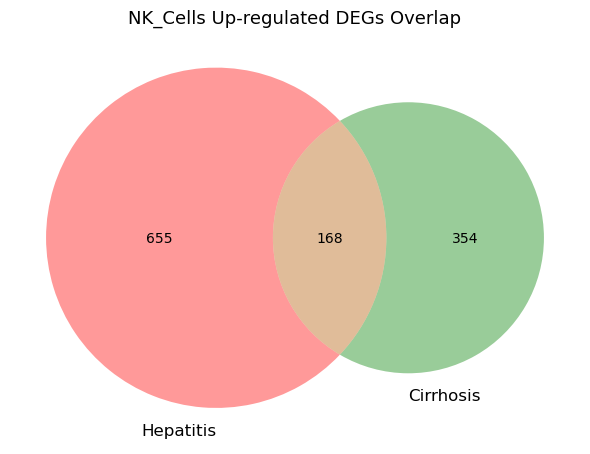

Up-regulated 교집합: 168
Hepatitis only Up: 655
Cirrhosis only Up: 354


In [21]:
# NK_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('NK_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

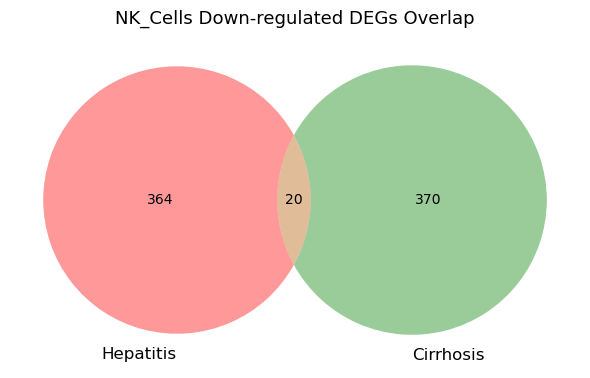

Down-regulated 교집합: 20
Hepatitis only Down: 364
Cirrhosis only Down: 370


In [22]:
# NK_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('NK_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [23]:
# NK_Cells overlap 유전자 저장
ct = 'NKcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

NKcell overlap genes saved:
  Cirrhosis only Up: 354
  Hepatitis only Up: 655
  Cirrhosis only Down: 370
  Hepatitis only Down: 364


## Endothelial_Cells

In [24]:
# Endothelial_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Endothelial.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Endothelial.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 13418
Hepatitis total DEGs: 14568
Cirrhosis significant: 3735 (Up: 1901, Down: 1834)
Hepatitis significant: 113 (Up: 9, Down: 104)


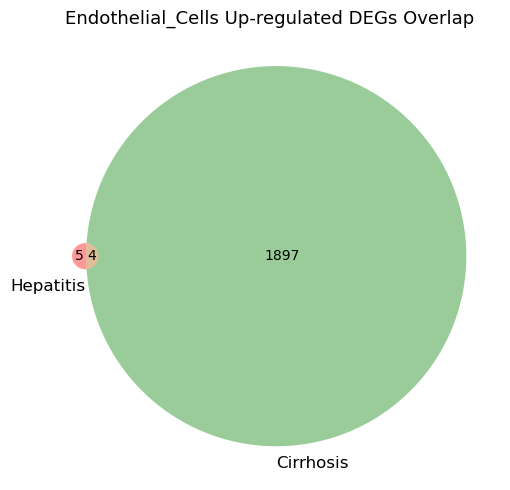

Up-regulated 교집합: 4
Hepatitis only Up: 5
Cirrhosis only Up: 1897


In [25]:
# Endothelial_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Endothelial_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

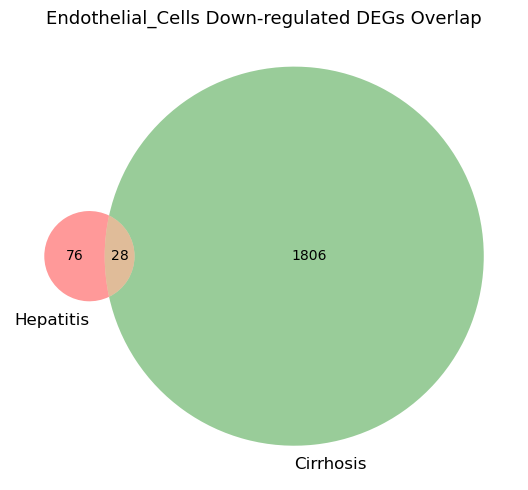

Down-regulated 교집합: 28
Hepatitis only Down: 76
Cirrhosis only Down: 1806


In [26]:
# Endothelial_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Endothelial_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [27]:
# Endothelial_Cells overlap 유전자 저장
ct = 'Endothelial'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Endothelial overlap genes saved:
  Cirrhosis only Up: 1897
  Hepatitis only Up: 5
  Cirrhosis only Down: 1806
  Hepatitis only Down: 76


## Plasma_Cells

In [28]:
# Plasma_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Plasmacell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Plasmacell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 12827
Hepatitis total DEGs: 8398
Cirrhosis significant: 256 (Up: 205, Down: 51)
Hepatitis significant: 94 (Up: 62, Down: 32)


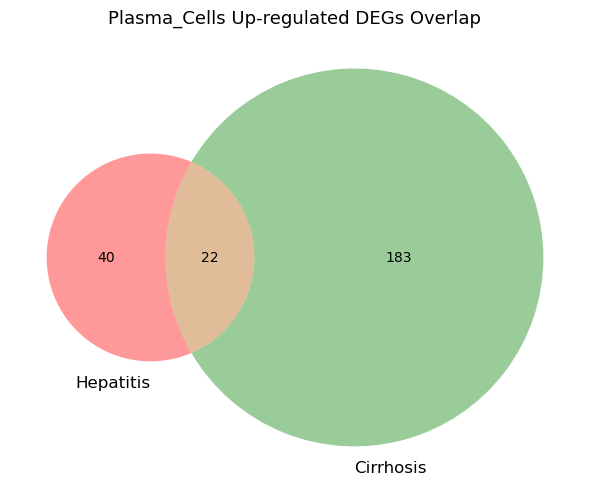

Up-regulated 교집합: 22
Hepatitis only Up: 40
Cirrhosis only Up: 183


In [29]:
# Plasma_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Plasma_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

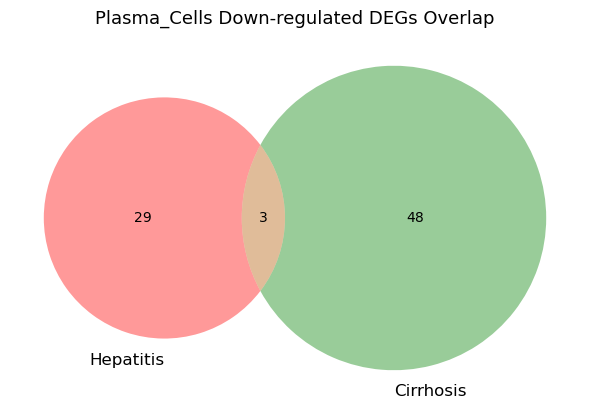

Down-regulated 교집합: 3
Hepatitis only Down: 29
Cirrhosis only Down: 48


In [30]:
# Plasma_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Plasma_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [31]:
# Plasma_Cells overlap 유전자 저장
ct = 'Plasmacell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Plasmacell overlap genes saved:
  Cirrhosis only Up: 183
  Hepatitis only Up: 40
  Cirrhosis only Down: 48
  Hepatitis only Down: 29


## DCs

In [32]:
# DCs 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_DC.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_DC.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 14332
Hepatitis total DEGs: 11174
Cirrhosis significant: 112 (Up: 80, Down: 32)
Hepatitis significant: 135 (Up: 85, Down: 50)


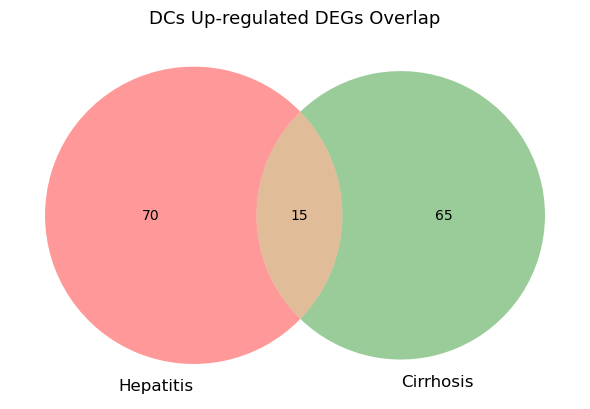

Up-regulated 교집합: 15
Hepatitis only Up: 70
Cirrhosis only Up: 65


In [33]:
# DCs Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('DCs Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

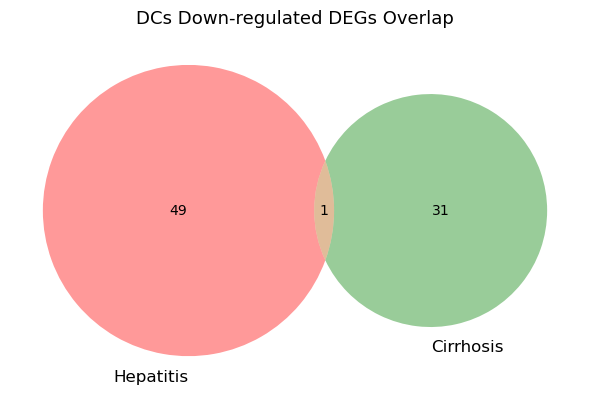

Down-regulated 교집합: 1
Hepatitis only Down: 49
Cirrhosis only Down: 31


In [34]:
# DCs Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('DCs Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [35]:
# DCs overlap 유전자 저장
ct = 'DC'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

DC overlap genes saved:
  Cirrhosis only Up: 65
  Hepatitis only Up: 70
  Cirrhosis only Down: 31
  Hepatitis only Down: 49


## B_Cells

In [36]:
# B_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Bcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Bcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 12254
Hepatitis total DEGs: 10068
Cirrhosis significant: 31 (Up: 29, Down: 2)
Hepatitis significant: 12 (Up: 12, Down: 0)


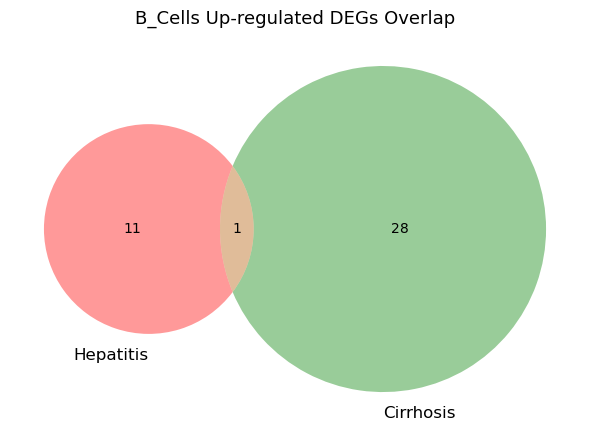

Up-regulated 교집합: 1
Hepatitis only Up: 11
Cirrhosis only Up: 28


In [37]:
# B_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('B_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

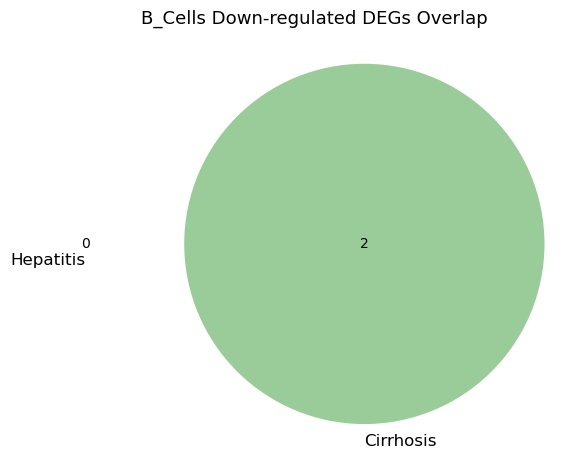

Down-regulated 교집합: 0
Hepatitis only Down: 0
Cirrhosis only Down: 2


In [38]:
# B_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('B_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [39]:
# B_Cells overlap 유전자 저장
ct = 'Bcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Bcell overlap genes saved:
  Cirrhosis only Up: 28
  Hepatitis only Up: 11
  Cirrhosis only Down: 2
  Hepatitis only Down: 0
